# Headers

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import sys
import os

import comet_ml
import json

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, classification_report

from catboost import CatBoostClassifier

try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()
    
parent_dir = os.path.join(current_dir, '..', '..', '..')
sys.path.insert(0, parent_dir)
    
    
from analysis_scripts.config import CFG
from analysis_scripts.selection_scripts import create_best_selection_path


CFG.seed_all(CFG.seed)
sns.set_theme(style='ticks')

CUDA available: False
Use CPU, 
Number of CPUs: 12


# Load preprocessed data

In [2]:
train_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/proc_df_train_2.csv').drop('Unnamed: 0', axis=1)
test_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/proc_df_test_1.csv').drop('Unnamed: 0', axis=1)

assert not train_df.isna().sum().sum(), 'Train, data containes NaNs!!'
assert not test_df.isna().sum().sum(), 'Test, data containes NaNs!!'

# Prepare Data

Exclude variables that affect background shape: 
* is_mass_window,
* mass_Lc,
* mass_pt_correlation
* ?Mt_Lc?

In [3]:
# Comet logger
# experiment = comet_ml.Experiment(
#     project_name="SPD ML",
#     workspace="artem-smirnov",
#     api_key="yyKk8vacVuy8dbttSCIgF2iQO"
# )

x = train_df.drop(['tag'], axis=1).copy()
y = train_df['tag'].map({'Sig': 1, 'Bg': 0}).copy()

x_train_full, x_val_full, y_train, y_val = train_test_split(x, y, test_size=0.2, shuffle=True, stratify=y, random_state=CFG.seed)

features_list = CFG.feature_set_3

x_train = x_train_full[features_list].copy()
x_val = x_val_full[features_list].copy()

x_test_full = test_df.drop(['tag'], axis=1).copy()

x_test = test_df[features_list].copy()
y_test = test_df['tag'].map({'Sig': 1, 'Bg': 0}).copy()


try:
    experiment.set_name('feature_set_1, params_xgboost_1')
    formatted_text = json.dumps({"feature_names": features_list}, indent=2)
    experiment.log_text(text=formatted_text)
except NameError:
    pass

In [4]:
# Feature encoding
if features_list == CFG.feature_set_1:
    cols_to_encode = [
        'highest_pt_daughter', 'highest_momentum_daughter', 'highest_OA_daughter',
        'highest_eta_daughter', 'highest_dca_Lc_daughter', 'highest_dca_PV_daughter',
    ]
elif features_list == CFG.feature_set_2:
    cols_to_encode = [
        'highest_momentum_daughter',
        'highest_eta_daughter', 'highest_dca_Lc_daughter', 'highest_dca_PV_daughter',
    ]
elif features_list == CFG.feature_set_3:
    cols_to_encode = ['highest_momentum_daughter']

preprocessor = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(sparse_output=False, dtype=int), cols_to_encode)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

preprocessor.fit(x_train)
x_train_encoded = preprocessor.transform(x_train)
x_val_encoded = preprocessor.transform(x_val)
x_test_encoded = preprocessor.transform(x_test)

feature_names = preprocessor.get_feature_names_out()

x_train = pd.DataFrame(x_train_encoded, columns=feature_names, index=x_train.index)
x_val = pd.DataFrame(x_val_encoded, columns=feature_names, index=x_val.index)
x_test = pd.DataFrame(x_test_encoded, columns=feature_names, index=x_test.index)


# Drop excluded columns
if features_list == CFG.feature_set_2:
    
    features_to_drop = [
        'highest_momentum_daughter_P_pip', 'highest_momentum_daughter_P_p',
        'highest_eta_daughter_eta_pip', 'highest_dca_PV_daughter_dist_pip_PV_xy',
        'highest_dca_Lc_daughter_dist_p_Lc_xy',
    ]

    x_train = x_train.drop(columns=features_to_drop)
    x_val = x_val.drop(columns=features_to_drop)
    x_test = x_test.drop(columns=features_to_drop)
    
elif features_list == CFG.feature_set_3:
    
    features_to_drop = [
        'highest_momentum_daughter_P_pip', 'highest_momentum_daughter_P_p',
    ]
    
    x_train = x_train.drop(columns=features_to_drop)
    x_val = x_val.drop(columns=features_to_drop)
    x_test = x_test.drop(columns=features_to_drop)

In [5]:
for feature in features_list:
    
    if feature in CFG.cols_to_log_transform:
        pass
        # x_train[feature + '_log'] = np.log1p(x_train[feature])
        # x_val[feature + '_log'] = np.log1p(x_val[feature])
        # x_test[feature + '_log'] = np.log1p(x_test[feature])
    
    if feature in CFG.continual_features:
        pass
        # x_train[feature + '_pct'] = x_train[feature].rank(pct=True)
        # x_val[feature + '_pct'] = x_val[feature].rank(pct=True)
        # x_test[feature + '_pct'] = x_test[feature].rank(pct=True)
        
        # x_train[feature + '_bin'] = pd.cut(x_train[feature], bins=10, labels=False)
        # x_val[feature + '_bin'] = pd.cut(x_train[feature], bins=10, labels=False)
        # x_test[feature + '_bin'] = pd.cut(x_train[feature], bins=10, labels=False)

# CatBoost

### Feature Importance

#### CatBoost FE

In [ ]:
from catboost import CatBoostClassifier


params = {}
params.update({
    'loss_function': 'Logloss',
    # 'grow_policy': 'SymmetricTree',
    'eval_metric': 'AUC',
    'use_best_model': True,
    'task_type': 'GPU' if CFG.gpu_available else 'CPU',
    'border_count': 256,
    'verbose': 0,
    'thread_count': 1 if CFG.gpu_available else 6,
    'random_seed': CFG.seed,
})

model = CatBoostClassifier(**params)
model.fit(
    x_train,
    y_train,
    eval_set=(x_val, y_val),
    plot=False
)

for importance_type in ['PredictionValuesChange', 'FeatureImportance']:
    
    feature_names = x_train.columns
    importance_scores = model.get_feature_importance(type='FeatureImportance')

    # Create DataFrame
    feature_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance_scores
    }).sort_values('importance', ascending=False)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 9))

    sns.barplot(
        data=feature_df,
        x='importance',
        y='feature',
        palette='viridis_r',
        orient='h'
    )

    plt.title(f'Feature Importances ({importance_type})- XGBoost Classifier', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    # plt.savefig('test.pdf', bbox_inches='tight', pad_inches=0.1, dpi=300)
    plt.show()

#### permutation_importance

In [ ]:
from sklearn.inspection import permutation_importance


params = {}
params.update({
    'loss_function': 'Logloss',
    # 'grow_policy': 'SymmetricTree',
    'eval_metric': 'AUC',
    'use_best_model': True,
    'task_type': 'GPU' if CFG.gpu_available else 'CPU',
    'border_count': 256,
    'verbose': 0,
    'thread_count': 1 if CFG.gpu_available else 6,
    'random_seed': CFG.seed,
})

model = CatBoostClassifier(**params)
model.fit(
    x_train,
    y_train,
    eval_set=(x_val, y_val),
    plot=False
)

# Calculate permutation importance
perm_importance = permutation_importance(model, x_val, y_val, n_repeats=10, random_state=CFG.seed)

# Create DataFrame
perm_df = pd.DataFrame({
    'feature': x_train.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

# Plot with error bars
fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=perm_df,
    x='importance',
    y='feature', 
    capsize=0.2,
    palette='viridis_r',
    ax=ax
)
plt.title('Feature Importances - Permutation Importance', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Importance (decrease in score)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

#### shap

In [ ]:
import shap
from catboost import CatBoostClassifier


params = {}
params.update({
    'loss_function': 'Logloss',
    # 'grow_policy': 'SymmetricTree',
    'eval_metric': 'AUC',
    'use_best_model': True,
    'task_type': 'GPU' if CFG.gpu_available else 'CPU',
    'border_count': 256,
    'verbose': 0,
    'thread_count': 1 if CFG.gpu_available else 6,
    'random_seed': CFG.seed,
})

model = CatBoostClassifier(**params)
model.fit(
    x_train,
    y_train,
    eval_set=(x_val, y_val),
    plot=False
)

explainer = shap.Explainer(model)
shap_values = explainer(x_train)
explanation = explainer(x_train)

In [ ]:
fig, ax = plt.subplots(figsize=(5, 14))
shap.plots.bar(shap_values, max_display=60, ax=ax)

In [ ]:
clustering = shap.utils.hclust(x_train, y_train)

In [ ]:
shap.plots.bar(shap_values, clustering=clustering, clustering_cutoff=0.4, max_display=60)

In [ ]:
shap.plots.beeswarm(shap_values, max_display=60, order=shap_values.abs.mean(0))

### Cross-validation

In [6]:
params = {}
params.update({
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'use_best_model': True,
    'task_type': 'GPU' if CFG.gpu_available else 'CPU',
    'border_count': 256,
    'verbose': 0,
    'thread_count': 1 if CFG.gpu_available else 6,
    'random_seed': CFG.seed,
})

try:
    experiment.log_parameters(params)
except NameError:
    pass

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CFG.seed)
split_generator = skf.split(x_train, y_train)

train_scores = []
val_scores = []
for fold, (train_idx, val_idx) in enumerate(split_generator):
    
    fold_x_train = x_train.iloc[train_idx, :]
    fold_y_train = y_train.iloc[train_idx]
    fold_x_val = x_train.iloc[val_idx, :]
    fold_y_val = y_train.iloc[val_idx]
    
    fold_model = CatBoostClassifier(**params)
    
    fold_model.fit(
        fold_x_train,
        fold_y_train,
        eval_set=(fold_x_val, fold_y_val),
        plot=False
    )
    
    fold_train_pred_proba = fold_model.predict_proba(fold_x_train)[:, 1]
    fold_val_pred_proba = fold_model.predict_proba(fold_x_val)[:, 1]
    
    fold_train_score = roc_auc_score(fold_y_train, fold_train_pred_proba)
    fold_val_score = roc_auc_score(fold_y_val, fold_val_pred_proba)
    
    train_scores.append(fold_train_score)
    val_scores.append(fold_val_score)

    print(f'\nFold {fold} result:  train score: {fold_train_score:0.3f}, val score: {fold_val_score: 0.3f}\n')


train_scores = np.array(train_scores)
val_scores = np.array(val_scores)

try:
    experiment.log_metrics({
        'cv_train_mean_roc_auc':  train_scores.mean(),
        'cv_val_mean_roc_auc':  val_scores.mean()
    })
except NameError:
    pass

print(f'\n\nMean CV train score: {train_scores.mean():0.3f}')
print(f'Mean CV val score: {val_scores.mean():0.3f}')


Fold 0 result:  train score: 0.986, val score:  0.978


Fold 1 result:  train score: 0.985, val score:  0.978


Fold 2 result:  train score: 0.986, val score:  0.978


Fold 3 result:  train score: 0.986, val score:  0.978


Fold 4 result:  train score: 0.986, val score:  0.978



Mean CV train score: 0.986
Mean CV val score: 0.978


### RFE

In [ ]:
from sklearn.feature_selection import RFECV


params = {}
params.update({
    'loss_function': 'Logloss',
    # 'grow_policy': 'SymmetricTree',
    'eval_metric': 'AUC',
    'use_best_model': True,
    'task_type': 'GPU' if CFG.gpu_available else 'CPU',
    'border_count': 256,
    'verbose': 0,
    'thread_count': 1 if CFG.gpu_available else 6,
    'random_seed': CFG.seed,
})

estimator = CatBoostClassifier(**params)

# Options: 'accuracy', 'roc_auc', 'f1', 'precision', 'recall', 'neg_log_loss'
selector = RFECV(
    estimator, 
    step=1, 
    cv=5, 
    scoring='roc_auc',
    n_jobs=6
)

selector = selector.fit(x_train, y_train)

mean_scores = selector.cv_results_['mean_test_score']
std_scores = selector.cv_results_['std_test_score']

optimal_score = np.max(mean_scores)
optimal_idx = np.argmax(mean_scores)

print("Optimal number of features:", selector.n_features_)
print(f"Best score: {optimal_score:.4f}")
print("Selected features:")
for feat in x_train.columns[selector.support_]:
    print(f"  - {feat}")
    
# Plot RFE
plt.figure(figsize=(14, 8))

n_features_range = range(selector.min_features_to_select, 
                        len(mean_scores) + selector.min_features_to_select)

df_scores = pd.DataFrame({
    'Number of Features': n_features_range,
    'Mean Score': mean_scores,
    'Std Score': std_scores
})

# (95% CI using 1.96 * std)
confidence_multiplier = 1.96
df_scores['Upper_CI'] = df_scores['Mean Score'] + confidence_multiplier * df_scores['Std Score']
df_scores['Lower_CI'] = df_scores['Mean Score'] - confidence_multiplier * df_scores['Std Score']


# sns.set_style("whitegrid")

# Confidence interval as filled area (95% CI)
plt.fill_between(df_scores['Number of Features'], 
                df_scores['Lower_CI'], 
                df_scores['Upper_CI'], 
                alpha=0.3, 
                color='steelblue',
                label='95% Confidence Interval')

line_plot = sns.lineplot(data=df_scores, 
                        x='Number of Features', 
                        y='Mean Score',
                        marker='o',
                        linewidth=2.5,
                        markersize=8,
                        color='steelblue',
                        label='Mean Score')

# Vertical line at optimal number of features
optimal_features = selector.n_features_
plt.axvline(x=optimal_features, color='red', linestyle='--', alpha=0.7, 
            linewidth=2, label=f'Optimal: {optimal_features} features')

# Add optimal point
optimal_point = plt.scatter(optimal_features, optimal_score, 
                        color='red', s=200, zorder=5, 
                        label=f'Optimal Score: {optimal_score:.4f}',
                        edgecolors='black', linewidth=2)


plt.title('RFECV Performance: Score vs Number of Features\n(with 95% Confidence Intervals)', 
        fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Features', fontsize=12, fontweight='bold')
plt.ylabel('Mean ROC-AUC Score', fontsize=12, fontweight='bold')
plt.xticks(list(n_features_range))
plt.grid(True, alpha=0.3)
plt.legend(loc='best', framealpha=0.9)

plt.tight_layout()
plt.show()

# Print results
print("\n" + "="*60)
print("Results (Mean +- 1.96*Std for 95% CI):")
print("="*60)

for i, (n_feat, mean_score, std_score) in enumerate(zip(n_features_range, mean_scores, std_scores)):
    ci_lower = mean_score - 1.96 * std_score
    ci_upper = mean_score + 1.96 * std_score
    marker = " ← OPTIMAL" if n_feat == optimal_features else ""
    print(f"Features: {n_feat:2d} | Score: {mean_score:.4f} | "
        f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]{marker}")

print("="*60)

# plt.savefig('test.pdf', bbox_inches='tight', pad_inches=0.1, dpi=300)

### Single Model Estimation

#### Create model

In [6]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, classification_report


params = {}
params.update({
    'loss_function': 'Logloss',
    # 'grow_policy': 'SymmetricTree',
    'eval_metric': 'AUC',
    'use_best_model': True,
    'task_type': 'GPU' if CFG.gpu_available else 'CPU',
    'border_count': 256,
    'verbose': 0,
    'thread_count': 1 if CFG.gpu_available else 6,
    'random_seed': CFG.seed,
})

model = CatBoostClassifier(**params)
model.fit(
    x_train,
    y_train,
    eval_set=(x_val, y_val),
    plot=True
)

# Evaluate on train set
y_pred_train = model.predict(x_train)
y_pred_proba_train = model.predict_proba(x_train)[:, 1]

print(f'\n{'#'*60}')
print(f"Train set performance:\n")
print(classification_report(y_true=y_train, y_pred=y_pred_train))
print(f"ROC-AUC: {roc_auc_score(y_train, y_pred_proba_train):.4f}")

try:
    experiment.log_metric(name='classification_report', value=classification_report(y_train, y_pred_proba_train))
    experiment.log_metric(name='roc_auc_score', value=roc_auc_score(y_train, y_pred_proba_train))
except NameError:
    pass

# Evaluate on val set
y_pred_val = model.predict(x_val)
y_pred_proba_val = model.predict_proba(x_val)[:, 1]

print(f'\n{'#'*60}')
print(f"Val set performance:\n")
print(classification_report(y_true=y_val, y_pred=y_pred_val))
print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_proba_val):.4f}")

try:
    experiment.log_metric(name='classification_report', value=classification_report(y_val, y_pred_proba_val))
    experiment.log_metric(name='roc_auc_score', value=roc_auc_score(y_val, y_pred_proba_val))
except NameError:
    pass

# Evaluate on test set
y_pred_test = model.predict(x_test)
y_pred_proba_test = model.predict_proba(x_test)[:, 1]

print(f'\n{'#'*60}')
print(f"Test set performance:\n")
print(classification_report(y_true=y_test, y_pred=y_pred_test))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_test):.4f}")

try:
    experiment.log_metric(name='classification_report', value=classification_report(y_test, y_pred_proba_test))
    experiment.log_metric(name='roc_auc_score', value=roc_auc_score(y_test, y_pred_proba_test))
except NameError:
    pass

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))


############################################################
Train set performance:

              precision    recall  f1-score   support

           0       0.96      0.96      0.96    177607
           1       0.87      0.88      0.87     59485

    accuracy                           0.94    237092
   macro avg       0.91      0.92      0.92    237092
weighted avg       0.94      0.94      0.94    237092

ROC-AUC: 0.9814

############################################################
Val set performance:

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     44402
           1       0.85      0.85      0.85     14871

    accuracy                           0.92     59273
   macro avg       0.90      0.90      0.90     59273
weighted avg       0.92      0.92      0.92     59273

ROC-AUC: 0.9750

############################################################
Test set performance:

              precision    recall  f1-score   support

    

#### Classifier Calibration

/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:589: FutureWarning: y_pred is deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(
/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:589: FutureWarning: y_pred is deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(
/home/ome123/python_envs/gen_DA-env/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:589: FutureWarning: y_pred is deprecated in 1.7 and will be removed in 1.9. Please use `y_score` instead.
  warnings.warn(


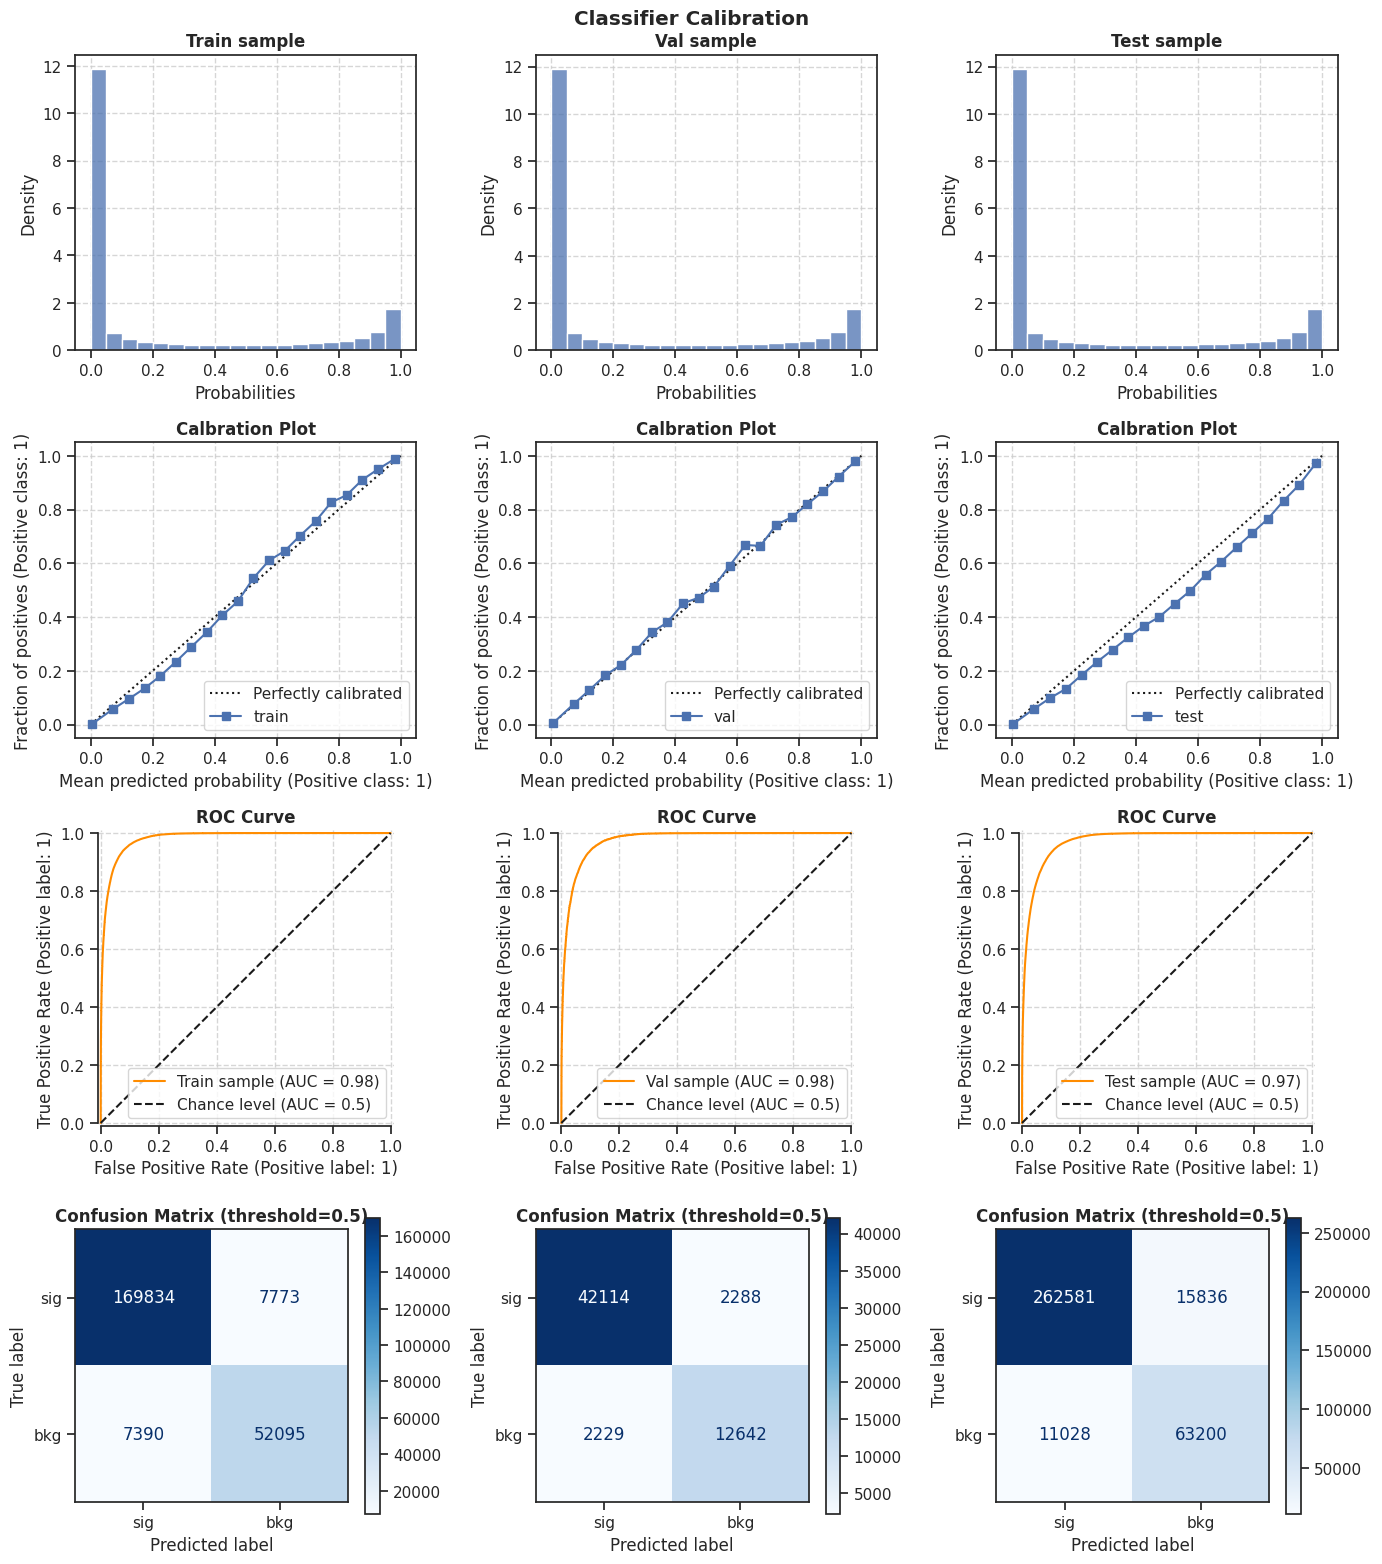

In [7]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay


n_bins=20

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(14, 16))
fig.suptitle('Classifier Calibration', fontweight='bold')

#######################################
sns.histplot(
    data=y_pred_proba_train,
    stat='density',
    bins=n_bins,
    ax=axes[0][0]
)

axes[0][0].set_title('Train sample', fontweight='bold')
axes[0][0].set_xlabel('Probabilities')
axes[0][0].set_ylabel('Density')
axes[0][0].grid(True, linestyle='--', alpha=0.8)
#######################################
disp = CalibrationDisplay.from_predictions(y_train, y_pred_proba_train, name='train', n_bins=n_bins, ax=axes[1][0])

axes[1][0].set_title('Calbration Plot', fontweight='bold')
# axes[1][0].set_xlabel('Probabilities', fontweight='bold')
# axes[1][0].set_ylabel('Density', fontweight='bold')
axes[1][0].grid(True, linestyle='--', alpha=0.8)
#######################################
display = RocCurveDisplay.from_predictions(
    y_true=y_train,
    y_pred=y_pred_proba_train,
    name=f"Train sample",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
    ax=axes[2][0]
)

axes[2][0].set_title('ROC Curve', fontweight='bold')
axes[2][0].grid(True, linestyle='--', alpha=0.8)
#######################################
ConfusionMatrixDisplay.from_predictions(
    y_true=y_train, 
    y_pred=y_pred_train,
    display_labels=['sig', 'bkg'],
    cmap=plt.cm.Blues,
    values_format='d',
    ax=axes[3][0]
)

axes[3][0].set_title('Confusion Matrix (threshold=0.5)', fontweight='bold')
#######################################
sns.histplot(
    data=y_pred_proba_val,
    stat='density',
    bins=n_bins,
    ax=axes[0][1]
)

axes[0][1].set_title('Val sample', fontweight='bold')
axes[0][1].set_xlabel('Probabilities')
axes[0][1].set_ylabel('Density')
axes[0][1].grid(True, linestyle='--', alpha=0.8)
#######################################
disp = CalibrationDisplay.from_predictions(y_val, y_pred_proba_val, name='val', n_bins=n_bins, ax=axes[1][1])

axes[1][1].set_title('Calbration Plot', fontweight='bold')
# axes[1][0].set_xlabel('Probabilities', fontweight='bold')
# axes[1][0].set_ylabel('Density', fontweight='bold')
axes[1][1].grid(True, linestyle='--', alpha=0.8)
#######################################
display = RocCurveDisplay.from_predictions(
    y_true=y_val,
    y_pred=y_pred_proba_val,
    name=f"Val sample",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
    ax=axes[2][1]
)

axes[2][1].set_title('ROC Curve', fontweight='bold')
axes[2][1].grid(True, linestyle='--', alpha=0.8)
#######################################
ConfusionMatrixDisplay.from_predictions(
    y_true=y_val, 
    y_pred=y_pred_val,
    display_labels=['sig', 'bkg'],
    cmap=plt.cm.Blues,
    values_format='d',
    ax=axes[3][1]
)

axes[3][1].set_title('Confusion Matrix (threshold=0.5)', fontweight='bold')
#######################################
sns.histplot(
    data=y_pred_proba_val,
    stat='density',
    bins=n_bins,
    ax=axes[0][2]
)

axes[0][2].set_title('Test sample', fontweight='bold')
axes[0][2].set_xlabel('Probabilities')
axes[0][2].set_ylabel('Density')
axes[0][2].grid(True, linestyle='--', alpha=0.8)
#######################################
disp = CalibrationDisplay.from_predictions(y_test, y_pred_proba_test, name='test', n_bins=n_bins, ax=axes[1][2])

axes[1][2].set_title('Calbration Plot', fontweight='bold')
# axes[1][0].set_xlabel('Probabilities', fontweight='bold')
# axes[1][0].set_ylabel('Density', fontweight='bold')
axes[1][2].grid(True, linestyle='--', alpha=0.8)
#######################################
display = RocCurveDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_pred_proba_test,
    name=f"Test sample",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
    ax=axes[2][2]
)

axes[2][2].set_title('ROC Curve', fontweight='bold')
axes[2][2].grid(True, linestyle='--', alpha=0.8)
#######################################
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test, 
    y_pred=y_pred_test,
    display_labels=['sig', 'bkg'],
    cmap=plt.cm.Blues,
    values_format='d',
    ax=axes[3][2]
)

axes[3][2].set_title('Confusion Matrix (threshold=0.5)', fontweight='bold')
#######################################
plt.tight_layout()

try:
    experiment.log_figure(
        figure_name=f"Calibration plots",
        figure=plt.gcf()
    )
except NameError:
    pass

plt.show()

#### Optimize threshold

In [8]:
from analysis_scripts.estimate_scripts import signal_estimates
from sklearn.metrics import f1_score, precision_score


# From data_explore section
sig_eff_presel = 0.7241826749529263
bg_eff_presel = 0.49130648841423924

#---------------
# Get raw df
data_oc_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_signal_2.csv', usecols=['mass_Lc', 'true_decay'])
data_mb_df = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_background_2.csv', usecols=['mass_Lc', 'true_decay'])

mass_mask = (data_oc_df['mass_Lc'] > CFG.mass_interval[0]) \
            & ( data_oc_df['mass_Lc'] < CFG.mass_interval[1]) \
            & (data_oc_df['true_decay'] == 1)

data_oc_df = data_oc_df[mass_mask]
data_oc_df['tag'] = 'Sig'

mass_mask = (data_mb_df['mass_Lc'] > CFG.mass_interval[0]) & ( data_mb_df['mass_Lc'] < CFG.mass_interval[1])

data_mb_df = data_mb_df[mass_mask]
data_mb_df['tag'] = 'Bg'

raw_df = pd.concat([data_oc_df, data_mb_df], axis=0).reset_index(drop=True)
#---------------

pred_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred_proba': y_pred_proba_test
})

thresholds = np.arange(0.1, 1, 0.05)
f1_scores = []
precision_scores = []
s_over_b = []

for threshold in thresholds:
    
    signal_counts_after = pred_df.loc[(pred_df.y_pred_proba >= threshold) & (pred_df.y_true == 1), 'y_true'].count()
    signal_counts_before = pred_df.loc[pred_df.y_true == 1, 'y_true'].count()
    background_counts_after = pred_df.loc[(pred_df.y_pred_proba >= threshold) & (pred_df.y_true == 0), 'y_true'].count()
    background_counts_before = pred_df.loc[pred_df.y_true == 0, 'y_true'].count()

    signal_eff_ML = signal_counts_after / signal_counts_before
    background_eff_ML = background_counts_after / background_counts_before

    total_sig_efficiency = sig_eff_presel * signal_eff_ML
    total_bg_suppression = bg_eff_presel * background_eff_ML

    sig_mass_distr = raw_df.loc[raw_df['tag'] == 'Sig', 'mass_Lc']
    bg_mass_distr = raw_df.loc[raw_df['tag'] == 'Bg', 'mass_Lc']

    overall_s_b, *_ = signal_estimates(
        sig_mass_distr=sig_mass_distr,
        bg_mass_distr=bg_mass_distr,
        have_sig_events=CFG.have_sig_events_2 / total_sig_efficiency, 
        have_bg_events=CFG.have_bg_events_2 / total_bg_suppression,
        mass_interval=CFG.mass_interval, 
        visualization=False,
        verbose=False
    )
    
    f1_scores.append(f1_score(y_test, np.where(y_pred_proba_test > threshold, 1, 0)))
    precision_scores.append(precision_score(y_test, np.where(y_pred_proba_test > threshold, 1, 0)))
    s_over_b.append(overall_s_b)
    
res_df = pd.DataFrame({
    'threshold': thresholds,
    'f1_score': f1_scores,
    'precision': precision_scores,
    's_over_b': s_over_b
})
res_df

,threshold,f1_score,precision,s_over_b
0,0.10,0.743875,0.599823,0.000102
1,0.15,0.769681,0.639162,0.000121
2,0.20,0.788313,0.671058,0.000139
3,0.25,0.801373,0.697411,0.000157
4,0.30,0.810779,0.720587,0.000176
5,0.35,0.817506,0.741851,0.000196
6,0.40,0.821896,0.761983,0.000218
7,0.45,0.824143,0.780962,0.000243
8,0.50,0.824721,0.799636,0.000272
9,0.55,0.822708,0.818045,0.000306


In [9]:
optimal_threshold = 0.5

#### Physics Evaluation

In [10]:
from analysis_scripts.estimate_scripts import signal_estimates

threshold = optimal_threshold

pred_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred_proba': y_pred_proba_test
})

signal_counts_after = pred_df.loc[(pred_df.y_pred_proba >= threshold) & (pred_df.y_true == 1), 'y_true'].count()
signal_counts_before = pred_df.loc[pred_df.y_true == 1, 'y_true'].count()
background_counts_after = pred_df.loc[(pred_df.y_pred_proba >= threshold) & (pred_df.y_true == 0), 'y_true'].count()
background_counts_before = pred_df.loc[pred_df.y_true == 0, 'y_true'].count()

signal_eff_ML = signal_counts_after / signal_counts_before
background_eff_ML = background_counts_after / background_counts_before

total_sig_efficiency = sig_eff_presel * signal_eff_ML
total_bg_suppression = bg_eff_presel * background_eff_ML

try:
    experiment.log_metrics({
        'signal_eff_ML': signal_eff_ML,
        'background_eff_ML': background_eff_ML
    })
except NameError:
    pass

print(f'ML signal efficiency: {signal_eff_ML}')
print(f'ML background efficiency: {background_eff_ML}')
print(f'Total signal efficiency: {total_sig_efficiency}')
print(f'Total background efficiency: {total_bg_suppression}')

sig_mass_distr = raw_df.loc[raw_df['tag'] == 'Sig', 'mass_Lc']
bg_mass_distr = raw_df.loc[raw_df['tag'] == 'Bg', 'mass_Lc']

_ = signal_estimates(
    sig_mass_distr=sig_mass_distr,
    bg_mass_distr=bg_mass_distr,
    have_sig_events=CFG.have_sig_events_2 / total_sig_efficiency, 
    have_bg_events=CFG.have_bg_events_2 / total_bg_suppression,
    mass_interval=CFG.mass_interval, 
    visualization=False,
    verbose=True
)


ML signal efficiency: 0.8514307269493991
ML background efficiency: 0.05687871071091205
Total signal efficiency: 0.6165913813793304
Total background efficiency: 0.027944879624907576

SUMMARY STATISTICS
Total Signal Events: 12918080
Total Background Events: 47550427510
Total Signal Events Unscaled: 102499
Total Background Events Unscaled: 566687
Overall S/B Ratio: 0.000272
Overall S/sqrt(S+B) Significance: 59.23


#### Background shape check

KS-test: distributions are different, (alpha=0.05, p_value=0.000)


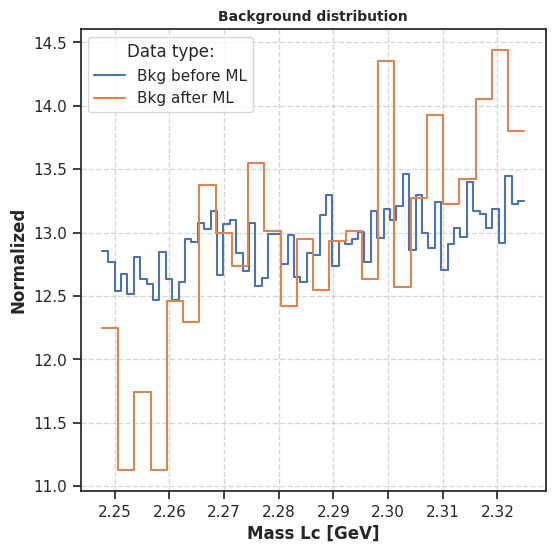

In [11]:
from scipy import stats


threshold = optimal_threshold
alpha = 0.05

df = test_df[['mass_Lc']].copy()
df['y_true'] = y_test
df['y_pred_proba'] = y_pred_proba_test

bkg_before_ML = df.loc[df.y_true == 0, 'mass_Lc']
bkg_after_Ml = df.loc[(df.y_pred_proba >= threshold) & (df.y_true == 0), 'mass_Lc']

# kolmogorov-Smirnov test
_, p_value = stats.ks_2samp(bkg_before_ML, bkg_after_Ml, alternative='two-sided')

try:
    experiment.log_metric(name='KS-test p-value', value=p_value)
except NameError:
    pass

if p_value >= alpha:
    print(f'KS-test: distributions are identical, ({alpha=}, {p_value=:0.3f})')
else:
    print(f'KS-test: distributions are different, ({alpha=}, {p_value=:0.3f})')


fig, ax = plt.subplots(figsize=(6, 6))

sns.histplot(
    data=bkg_before_ML,
    label='Bkg before ML',
    element='step',
    fill=False,
    stat='density',
    # alpha=0.8,
    ax=ax
)

sns.histplot(
    data=bkg_after_Ml,
    label='Bkg after ML',
    element='step',
    fill=False,
    stat='density',
    # alpha=0.8,
    ax=ax
)

plt.legend(title="Data type:", loc= "best")

ax.set_title('Background distribution', fontsize=10, fontweight='bold')
ax.set_xlabel('Mass Lc [GeV]', fontweight='bold')
ax.set_ylabel('Normalized', fontweight='bold')
ax.grid(True, alpha=0.8, linestyle='--')

try:
    experiment.log_figure(
        figure_name=f"Bkg distr ML",
        figure=plt.gcf()
    )
except NameError:
    pass

plt.show()

# End experiment log

In [ ]:
try:
    experiment.end()
except NameError:
    pass